# Explore here

In [1]:
# Your code here
import requests
from zipfile import ZipFile
from io import BytesIO
import os
import shutil

c:\Users\ayman\AppData\Local\Programs\Python\Python311\Lib\site-packages\requests\__init__.py:113: RequestsDependencyWarning: urllib3 (2.6.2) or chardet (6.0.0.post1)/charset_normalizer (3.3.2) doesn't match a supported version!
  warnings.warn(


In [2]:
#  Download the dataset
url = "https://storage.googleapis.com/datascience-materials/dogs-vs-cats.zip"
response = requests.get(url)

In [3]:
#  Extract to "dogs-vs-cats"
with ZipFile(BytesIO(response.content)) as zip_file:
    zip_file.extractall("dogs-vs-cats")

In [4]:
#  Correct the nested structure
# Original images are in: dogs-vs-cats/dogs-vs-cats/train/
source_train = "dogs-vs-cats/dogs-vs-cats/train"
dest_train = "dogs-vs-cats/train"

os.makedirs(dest_train, exist_ok=True)

In [5]:
# Move all images into a single folder first
for filename in os.listdir(source_train):
    src_path = os.path.join(source_train, filename)
    dst_path = os.path.join(dest_train, filename)
    shutil.move(src_path, dst_path)

In [16]:
for filename in os.listdir(dest_train):
    file_path = os.path.join(dest_train, filename)
    if os.path.isfile(file_path):  # Only move files not folders
        if filename.startswith("cat"):
            dst = os.path.join(cats_folder, filename)
            if not os.path.exists(dst):  # Only move if not already there
                shutil.move(file_path, cats_folder)
        elif filename.startswith("dog"):
            dst = os.path.join(dogs_folder, filename)
            if not os.path.exists(dst):  # Only move if not already there
                shutil.move(file_path, dogs_folder)

In [17]:
#  Load the dataset
import tensorflow as tf
train_dataset = tf.keras.utils.image_dataset_from_directory(
    dest_train,
    labels="inferred",
    label_mode="binary",
    batch_size=32,
    image_size=(150,150),
    shuffle=True
)

print("Dataset loaded successfully!")

Found 25000 files belonging to 2 classes.
Dataset loaded successfully!


In [8]:
import random
import shutil
import os
#creating test folder importing images into them
os.makedirs("dogs-vs-cats/test/cats", exist_ok=True)
os.makedirs("dogs-vs-cats/test/dogs", exist_ok=True)

train_cats = os.listdir("dogs-vs-cats/train/cats")
train_dogs = os.listdir("dogs-vs-cats/train/dogs")

for f in random.sample(train_cats, 500):
    shutil.move(f"dogs-vs-cats/train/cats/{f}","dogs-vs-cats/test/cats/{f}")
for f in random.sample(train_dogs, 500):
    shutil.move(f"dogs-vs-cats/train/dogs/{f}","dogs-vs-cats/test/dogs/{f}")

In [19]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Better data generator with augmentation
datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True,
    zoom_range=0.2
)

In [20]:
from tensorflow.keras import layers, models

model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(150,150,3)),
    layers.MaxPooling2D(2,2),
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),
    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),
    layers.Flatten(),
    layers.Dropout(0.5),
    layers.Dense(512, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

c:\Users\ayman\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [21]:
model.compile(optimizer='adam',
              loss ='binary_crossentropy',
              metrics=['accuracy'])

In [22]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 36992)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 36992)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 512)            │    18,940,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │           513 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,034,177 (72.61 MB)

 Trainable params: 19,034,177 (72.61 MB)

 Non-trainable params: 0 (0.00 B)

In [24]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=15,
    verbose=1
)

Epoch 1/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 177s 283ms/step - accuracy: 0.6543 - loss: 0.6115 - val_accuracy: 0.7368 - val_loss: 0.5196
Epoch 2/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 168s 269ms/step - accuracy: 0.7599 - loss: 0.4927 - val_accuracy: 0.7744 - val_loss: 0.4731
Epoch 3/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 166s 266ms/step - accuracy: 0.8033 - loss: 0.4277 - val_accuracy: 0.8086 - val_loss: 0.4153
Epoch 4/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 166s 266ms/step - accuracy: 0.8315 - loss: 0.3791 - val_accuracy: 0.8150 - val_loss: 0.4044
Epoch 5/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 166s 265ms/step - accuracy: 0.8616 - loss: 0.3179 - val_accuracy: 0.8282 - val_loss: 0.3891
Epoch 6/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 166s 265ms/step - accuracy: 0.8911 - loss: 0.2597 - val_accuracy: 0.8242 - val_loss: 0.3949
Epoch 7/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 165s 264ms/step - accuracy: 0.9233 - loss: 0.1906 - val_accuracy: 0.8328 - val_loss: 0.4422
Epoch 8/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 166s 265ms/step - accuracy: 0.9498 -

In [25]:
loss, accuracy = model.evaluate(val_data, verbose=2)
print(f"Validation Accuracy: {accuracy}")

157/157 - 8s - 53ms/step - accuracy: 0.8328 - loss: 0.7617
Validation Accuracy: 0.8327999711036682


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step


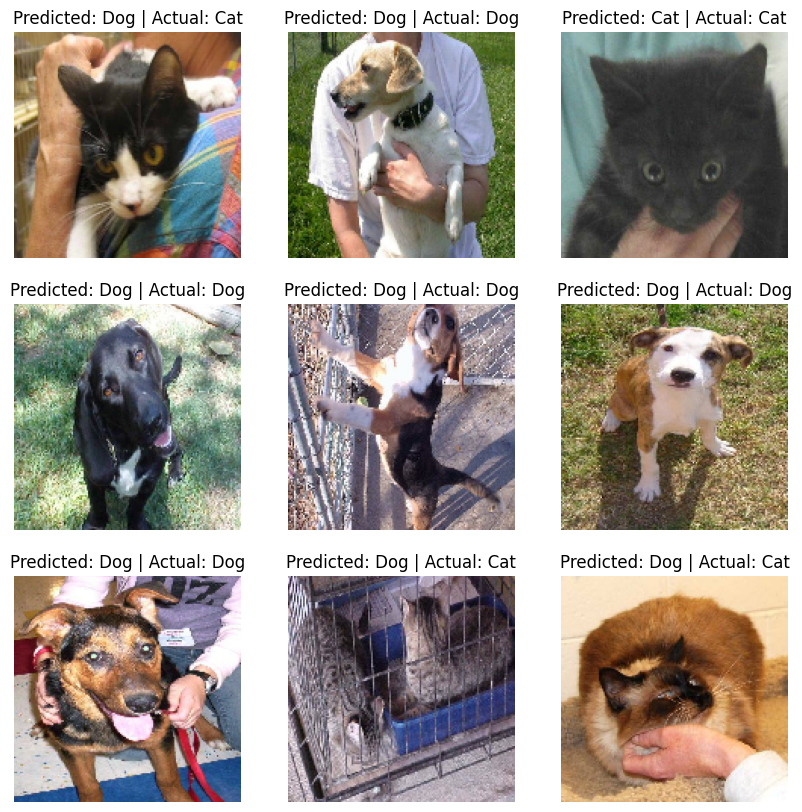

In [26]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10,10))
for i in range(9):  
    ax = plt.subplot(3,3,i+1)
    img, label = val_data[i]
    prediction = model.predict(tf.expand_dims(img[0], axis=0))
    plt.imshow(img[0])
    plt.title(f"Predicted: {'Dog' if prediction[0][0]>0.5 else 'Cat'} | Actual: {'Dog' if label[0]==1 else 'Cat'}")
    plt.axis("off")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step


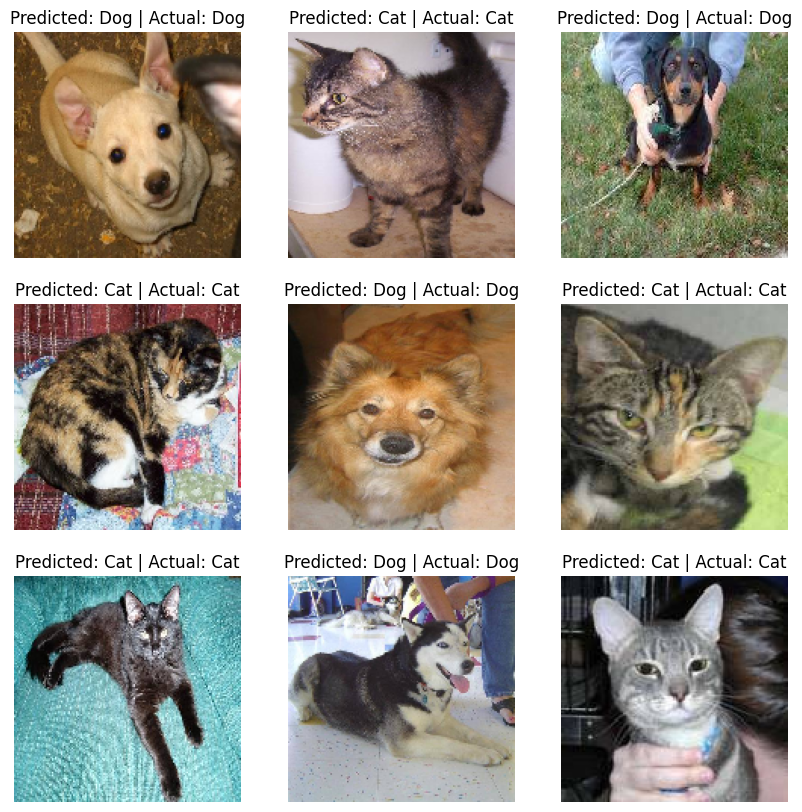

In [27]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10,10))
for i in range(9):  
    ax = plt.subplot(3,3,i+1)
    img, label = train_data[i]
    prediction = model.predict(tf.expand_dims(img[0], axis=0))
    plt.imshow(img[0])
    plt.title(f"Predicted: {'Dog' if prediction[0][0]>0.5 else 'Cat'} | Actual: {'Dog' if label[0]==1 else 'Cat'}")
    plt.axis("off")